In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import root_mean_squared_error

In [4]:
path=r"C:\artificial_intelligence_coarse\ad_ml\advertising.csv"

In [5]:
df=pd.read_csv(path)

In [6]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [8]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [9]:
df.shape

(200, 4)

In [10]:
df.size

800

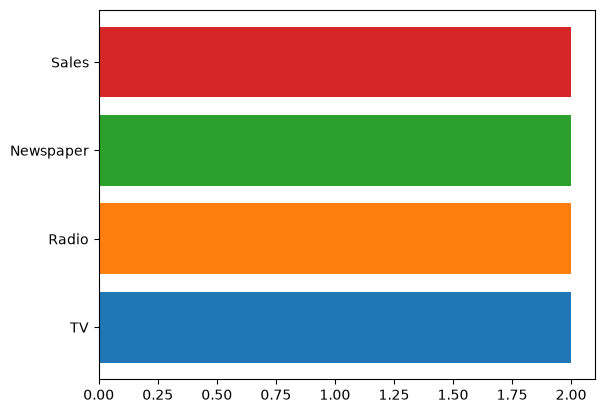

In [11]:
for i in df.columns:
    plt.barh(i,width=2)
    plt.plot(i)

Text(0, 0.5, 'range')

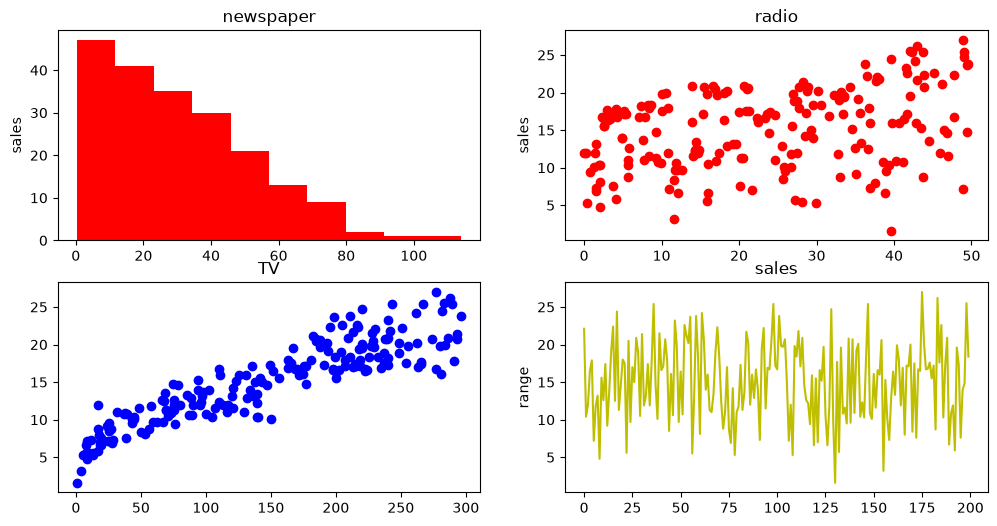

In [12]:
fig,ax=plt.subplots(2,2,figsize=(12,6))
ax[0,0].hist(df.Newspaper,color='red');ax[0,0].set_title("newspaper");ax[0,0].set_ylabel("range")
ax[0,1].scatter(df.Radio,df.Sales,color='red');ax[0,1].set_title("radio");ax[0,1].set_ylabel("sales")
ax[1,0].scatter(df.TV,df.Sales,color='b');ax[1,0].set_title("TV");ax[0,0].set_ylabel("sales")
ax[1,1].plot(df.Sales,color='y');ax[1,1].set_title("sales");ax[1,1].set_ylabel("range")

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [14]:
df.corrwith(df['Sales']).drop("Sales").sort_values(ascending=False)

TV           0.901208
Radio        0.349631
Newspaper    0.157960
dtype: float64

In [15]:
x=df[['TV','Radio','Newspaper']]
y=df['Sales']

In [16]:
x

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [17]:
y

0      22.1
1      10.4
2      12.0
3      16.5
4      17.9
       ... 
195     7.6
196    14.0
197    14.8
198    25.5
199    18.4
Name: Sales, Length: 200, dtype: float64

In [18]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=3)

In [19]:
model_lr=LinearRegression()

In [20]:
model_lr.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.05, 0.11,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.023
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [21]:
pred_by_lrmodel=model_lr.predict(xtest)
pred_by_lrmodel

array([17.94221632, 11.28731032, 19.36406753, 15.25309499,  8.85035488,
       11.08345095, 24.54827272, 10.72184726, 18.64190205, 17.03877174,
       14.71887065, 13.30204368, 19.10529921, 11.4654086 , 13.82417942,
       14.56139355, 16.86156735, 17.27369971, 17.78634747, 21.28201581,
       19.1397699 , 11.05346066,  9.93276334, 11.49854807,  8.5309559 ,
       13.26073545, 21.75566382, 16.96066432, 24.25791572, 11.92392893,
       16.40376866, 21.96064207,  9.51770237, 10.16209996, 10.08141197,
       10.45644324, 15.54919097,  9.92133897, 13.83425453, 12.54320065,
       14.5093965 , 12.61758414,  6.46804914, 20.25656292, 23.16303373,
       24.65508581, 15.20817964,  9.27513655, 18.72004324, 18.16217728,
       12.73063894, 16.65175796, 15.79776032,  8.36188762, 21.22771856,
        9.52094834, 23.88078008, 23.29062902, 19.6930198 , 16.76467522])

In [22]:
np.array(ytest)

array([16.6, 10.7, 20.7, 14.8,  8.4, 11.3, 26.2, 10.6, 18.3, 16.7, 17.6,
       13.6, 17. , 10.8, 12.9, 16.7, 16.9, 16.5, 17.1, 23.8, 19. , 10.4,
        9.2, 11.8,  8.7, 13.3, 24.7, 16.6, 23.8, 12. , 16. , 23.2,  7.3,
       11.9, 10.1, 14. , 17.9,  8.8, 13.4, 10.3, 15.3, 12.6,  3.2, 22.4,
       24.2, 27. , 15.5,  1.6, 20.5, 16. , 11.9, 19.7, 16.7,  5.7, 19.8,
        6.6, 24.4, 21.4, 16.8, 19.9])

In [23]:
lrmodelscore=model_lr.score(xtest,ytest)
lrmodelscore

0.8877675297095178

In [24]:
rmselr=root_mean_squared_error(ytest,pred_by_lrmodel)
rmselr

1.9043300760136959

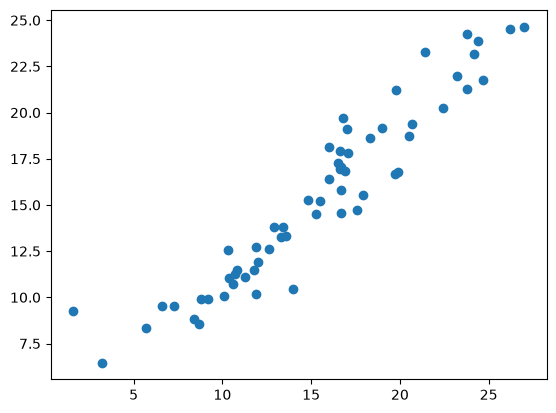

In [25]:
plt.scatter(ytest,pred_by_lrmodel)

<Axes: xlabel='Sales'>

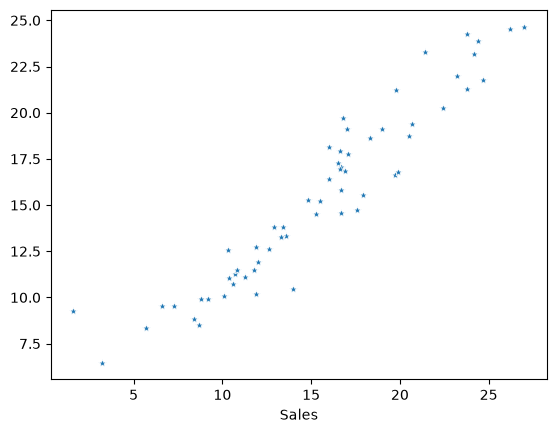

In [26]:
sns.scatterplot(x=ytest,y=pred_by_lrmodel,marker='*')

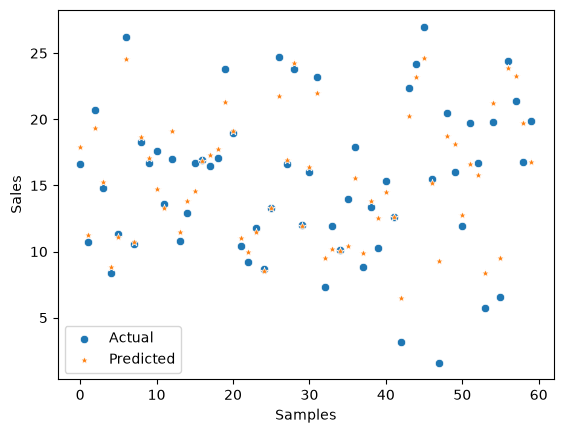

In [27]:
sns.scatterplot(x=range(len(ytest)), y=ytest, label='Actual', marker='o')
sns.scatterplot(x=range(len(pred_by_lrmodel)), y=pred_by_lrmodel, label='Predicted', marker='*')

plt.xlabel("Samples")
plt.ylabel("Sales")
plt.legend()
plt.show()

# KNN model

In [28]:
model_knn=KNeighborsRegressor(n_neighbors=5)

In [29]:
model_knn.fit(xtrain,ytrain)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


## predicted

In [30]:
pred_by_knn=model_knn.predict(xtest)
pred_by_knn

array([17.74, 12.6 , 19.62, 18.08,  9.02, 10.78, 22.  , 11.72, 20.26,
       17.96, 15.16, 12.4 , 18.14, 10.52, 11.66, 15.16, 17.24, 17.36,
       18.34, 21.86, 20.4 , 12.18,  9.1 , 10.5 ,  9.96, 13.  , 20.28,
       17.36, 22.  , 11.12, 15.24, 20.1 ,  6.92, 11.7 ,  9.66, 11.7 ,
       17.38,  9.12, 13.8 , 12.62, 14.1 , 12.48,  6.2 , 21.68, 23.86,
       22.64, 14.7 ,  7.4 , 18.56, 18.34, 11.66, 18.12, 15.76,  8.28,
       19.48,  7.72, 22.  , 21.52, 18.28, 18.22])

## actual

In [31]:
np.array(ytest)

array([16.6, 10.7, 20.7, 14.8,  8.4, 11.3, 26.2, 10.6, 18.3, 16.7, 17.6,
       13.6, 17. , 10.8, 12.9, 16.7, 16.9, 16.5, 17.1, 23.8, 19. , 10.4,
        9.2, 11.8,  8.7, 13.3, 24.7, 16.6, 23.8, 12. , 16. , 23.2,  7.3,
       11.9, 10.1, 14. , 17.9,  8.8, 13.4, 10.3, 15.3, 12.6,  3.2, 22.4,
       24.2, 27. , 15.5,  1.6, 20.5, 16. , 11.9, 19.7, 16.7,  5.7, 19.8,
        6.6, 24.4, 21.4, 16.8, 19.9])

In [32]:
model_knn.score(xtrain,ytrain)

0.9242683875500981

In [33]:
knnmodelscor=model_knn.score(xtest,ytest)
knnmodelscor

0.8912120447275775

In [34]:
rmseknn=root_mean_squared_error(ytest,pred_by_knn)
rmseknn

1.87487955168681

# comparison between both model

In [35]:
print(f"Linear model score : {lrmodelscore*100:.2f}\nKNN model score : {knnmodelscor*100:.2f}\
      \nROOT MEAN sqUared error of linear model :{rmselr:.2f}\
      \nROOT MEAN sqUared error of knn :{rmseknn:.2f}")
#jab root mean squared error jitna kam ho wohu model acha tasawwor kia jayi ga 

Linear model score : 88.78
KNN model score : 89.12      
ROOT MEAN sqUared error of linear model :1.90      
ROOT MEAN sqUared error of knn :1.87


In [49]:
model=['Linear Regression', 'KNN']
score=[lrmodelscore,knnmodelscor]

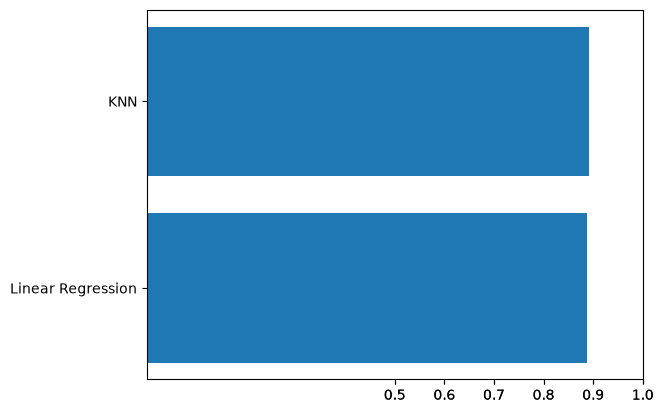

In [56]:
plt.barh(model,score)
plt.xticks(np.linspace(0.5,1,12).round(1))
plt.show()

## let check model on it actual data that what response both model gave

In [42]:
df.head(4)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5


In [37]:
checkmodel={
    'TV':[230,44,17,151],
    'Radio':[37,39,45,41],
    'Newspaper':[69,45,70,59]
}

In [39]:
check=pd.DataFrame(checkmodel)
check

,TV,Radio,Newspaper
0,230,37,69
1,44,39,45
2,17,45,70
3,151,41,59


In [40]:
print(model_knn.predict(check))

[20.28  9.88  9.14 17.36]


In [41]:
print(model_lr.predict(check))

[20.90257933 11.42924035 10.62921575 17.21496426]


Sales
22.1
10.4
12.0
16.5

In [44]:
if knnmodelscor>lrmodelscore:
    print(f"Best model : kneighber model ")
else:
    print("Best model : linear model ")

Best model : kneighber model 


# the end

<div style="background:#0d1117;border:1px solid #21262d;border-radius:16px;padding:28px 30px;font-family:'Segoe UI',system-ui,sans-serif;box-shadow:0 6px 20px rgba(0,0,0,0.4);margin-top:15px;">
  <div style="display:flex;align-items:center;border-bottom:1px solid #21262d;padding-bottom:16px;margin-bottom:16px;">
    <img src="https://github.com/mmilyas245-dot.png" alt="profile"
         style="width:56px;height:56px;border-radius:50%;margin-right:16px;flex-shrink:0;border:2px solid #00c6a2;object-fit:cover;" />
    <div>
      <div style="color:#ffffff;font-size:20px;font-weight:700;">Muhammad Ilyas</div>
      <div style="color:#00c6a2;font-size:14px;font-weight:500;">AI / Machine Learning /Deep Learning /RAG / LLM/ COMPUTER VISION / IoT</div>
    </div>
  </div>
  <div style="color:#8b949e;font-size:14px;line-height:1.9;">
    <div><span style="color:#00c6a2;">&#127891;</span>&nbsp; <b style="color:#c9d1d9;">Course:</b> Artificial Intelligence (Machine Learning &amp; Deep Learning)</div>
    <div><span style="color:#00c6a2;">&#127970;</span>&nbsp; <b style="color:#c9d1d9;">Program:</b> BS Artificial Intelligence &mdash; University of Peshawar&rsquo;s Pakistan &ldquo;Skills for All&rdquo;</div>
    <div style="margin-top:10px;display:flex;align-items:center;flex-wrap:wrap;gap:6px;">
      <img src="https://cdn.simpleicons.org/gmail/00c6a2?size=16" style="vertical-align:middle;" />
      <a href="mailto:mmilyas245@gmail.com" style="color:#58a6ff;text-decoration:none;">mmilyas245@gmail.com</a>
      &nbsp;&nbsp;|&nbsp;&nbsp;
      
      <a href="https://www.linkedin.com/in/muhammad-ilyas-76b18a287/" style="color:#58a6ff;text-decoration:none;">LinkedIn</a>
      &nbsp;&nbsp;|&nbsp;&nbsp;
      <img src="https://cdn.simpleicons.org/github/00c6a2?size=16" style="vertical-align:middle;" />
      <a href="https://github.com/mmilyas245-dot" style="color:#58a6ff;text-decoration:none;">GitHub</a>
    </div>
  </div>
  <div style="border-top:1px solid #21262d;margin-top:16px;padding-top:14px;text-align:center;">
    <span style="color:#6e7681;font-size:13px;font-style:italic;">
      &ldquo;The best way to predict the future is to create it.&rdquo;
    </span>
  </div>
  <div style="text-align:center;margin-top:10px;">
    <span style="color:#484f58;font-size:12px;">&copy; 2026 Muhammad Ilyas &nbsp;&bull;&nbsp; Made with &#10084;&#65039; for learning</span>
  </div>
</div>